In [1]:
# PREPARATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, roc_auc_score, confusion_matrix, f1_score

# Initialization
# Setting up paths and loading the metadata generated in Phase 03
ROOT = Path().resolve().parent
with open(ROOT / 'data/processed/dataset_info.json', 'r') as f:
    info = json.load(f)

def load_processed_data(dataset='ieee'):
    """
    Loads pre-processed parquet files and identifies feature sets.
    Rule 1 & 4 compliance: Using pre-split time-series data and defined features.
    """
    train = pd.read_parquet(ROOT / f'data/processed/{dataset}_train.parquet')
    test = pd.read_parquet(ROOT / f'data/processed/{dataset}_test.parquet')
    
    # Differentiating between Raw and Engineered features to measure impact
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    
    return train, test, raw_cols, eng_cols, all_cols

# Primary Dataset: IEEE-CIS (used for thorough analysis)
train_ieee, test_ieee, raw_ieee, eng_ieee, all_ieee = load_processed_data('ieee')
y_train, y_test = train_ieee['isFraud'], test_ieee['isFraud']

print(f"IEEE-CIS Loaded. Features: Raw({len(raw_ieee)}), Engineered({len(eng_ieee)})")


IEEE-CIS Loaded. Features: Raw(47), Engineered(17)


# MODEL 1 XGBoost
1. Our primary supervised modeling strategy focused on a multi-stage evolution of the XGBoost classifier. Initially, we conducted a Feature Ablation Study to isolate and quantify the uplift provided by our domain-specific engineering. By benchmarking "Raw" versus "Engineered" feature sets, we validated the necessity of behavioral aggregation (e.g., user transaction baselines). To address the extreme class imbalance, we implemented Algorithmic Balancing through the scale_pos_weight parameter, ensuring the loss function heavily penalizes missed fraud (False Negatives). This model serves as our Gold Standard, evaluated strictly on time-sequenced test data  using AUPRC to ensure real-world deployment reliability.
2. A Significant Leap in Model Discriminatory Power:
    Our experimental results demonstrate a substantial performance gain by integrating domain-specific behavioral features. The base XGBoost model achieved a strong AUPRC of 0.4918 using raw data. However, by incorporating user-centric aggregations, the Engineered XGBoost model reached an AUPRC of 0.6093. This 23.8% relative improvement is critical in a production environment; specifically, at a 50% recall rate (catching half of all frauds), our engineered model maintains a significantly higher precision, directly translating to fewer false alarms (Customer Friction) and higher operational efficiency for the fraud investigation team.

In [2]:
# Model 1: XGBoost (The Strong Supervised Baseline) 
# Handling Imbalance using scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Training XGBoost with Engineered Features...")
xgb_model = XGBClassifier(scale_pos_weight=ratio, n_estimators=200, max_depth=6, 
                         learning_rate=0.1, eval_metric='aucpr', random_state=42)

# Comparative Experiment: Raw Features Only vs. Raw + Engineered Features
#  (Addressing Feature Engineering Impact)
xgb_model.fit(train_ieee[raw_ieee], y_train)
y_scores_raw = xgb_model.predict_proba(test_ieee[raw_ieee])[:, 1]

xgb_model.fit(train_ieee[raw_ieee + eng_ieee], y_train)
y_scores_xgb = xgb_model.predict_proba(test_ieee[raw_ieee + eng_ieee])[:, 1]

# Evaluation
auprc_xgb_raw = average_precision_score(y_test, y_scores_raw)
auprc_xgb_full = average_precision_score(y_test, y_scores_xgb)

print(f"XGBoost Raw AUPRC: {auprc_xgb_raw:.4f}")
print(f"XGBoost Engineered AUPRC: {auprc_xgb_full:.4f}")

Training XGBoost with Engineered Features...
XGBoost Raw AUPRC: 0.4918
XGBoost Engineered AUPRC: 0.6093



# MODEL 2 LIGHTGBM
1.  Algorithm Comparison: Introducing LightGBM (Details: Building on XGBoost, we have introduced another mainstream gradient boosting algorithm, LightGBM.)
    Objective: To test the sensitivity of different algorithms to feature aggregation. LightGBM is typically faster and uses less memory than XGBoost when processing large datasets.
2. Summary: Feature Engineering Impact & Model Comparison
    2.1 Experimental Logic: We conducted a cross-model ablation study to quantify the value of our Phase 03 feature engineering. We benchmarked XGBoost and LightGBM using only Raw features versus the full Engineered set.
    2.2 Performance Results:
        XGBoost: Progressed from 0.4918 (Raw) to 0.6093 (Engineered), a +23.9% uplift.
        LightGBM: Progressed from 0.5124 (Raw) to 0.6132 (Engineered), a +19.7% uplift.

    2.3 Key Findings:
        Dominance of Engineering: Regardless of the algorithm, behavioral aggregation features (e.g., user transaction baselines) are the primary drivers of precision, significantly outperforming raw data.
        Algorithm Sensitivity: LightGBM achieved the highest overall score (0.6132), though XGBoost showed a higher relative improvement. This suggests LightGBM is inherently more robust with noisy raw data, while XGBoost benefits more dramatically from structured manual engineering.
        Deployment Choice: We recommend Engineered LightGBM for production due to its superior AUPRC and lower computational latency.

In [3]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score

# Model 2: LightGBM (Feature Impact Analysis)
# Logic: Benchmarking LightGBM's performance gain from Phase 03 engineering.
# We compare Raw Features vs. All Features (Raw + Engineered).

print("Evaluating LightGBM Feature Impact...")

# A. LightGBM with Raw Features ONLY
lgbm_raw = lgb.LGBMClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    n_estimators=500,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgbm_raw.fit(train_ieee[raw_ieee], y_train)
y_scores_lgbm_raw = lgbm_raw.predict_proba(test_ieee[raw_ieee])[:, 1]
auprc_lgbm_raw = average_precision_score(y_test, y_scores_lgbm_raw)

# B. LightGBM with All Features (Engineered)
lgbm_full = lgb.LGBMClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    n_estimators=500,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgbm_full.fit(train_ieee[all_ieee], y_train)
y_scores_lgbm_full = lgbm_full.predict_proba(test_ieee[all_ieee])[:, 1]
auprc_lgbm_full = average_precision_score(y_test, y_scores_lgbm_full)

print(f"LightGBM Raw AUPRC: {auprc_lgbm_raw:.4f}")
print(f"LightGBM Engineered AUPRC: {auprc_lgbm_full:.4f}")

Evaluating LightGBM Feature Impact...
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7299
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10416
[LightGBM] [Info] Number of data points in the train set: 472432, num

# MODEL 3 SMOTE
1.  Comparison of Strategies for Handling Imbalanced Data: 
    SMOTE Oversampling (Details: SMOTE (Synthetic Minority Over-sampling Technique) was introduced. Rather than simply duplicating fraud samples, it interpolates between existing fraud samples to “generate” new, similar virtual fraud cases.)
    Objective: To explore which approach is more effective: “algorithmic weighting” (telling the model that fraud is important) or “data augmentation” (providing the model with more fraud cases to analyze).

    Data Purity and Feature Isolation (Details: The code strictly adheres to the principle of splitting first, then sampling. SMOTE is run only on the training set; the test set remains unchanged.)
    Objective: To prevent data leakage. If we split the data after sampling, the model would generate inflated scores because it has “seen” similar synthetic samples.
    
2. Comparative Analysis of Balancing Strategies: Weights vs. Synthetic Sampling:
    Our benchmarking of advanced balancing techniques reveals a clear hierarchy in performance. LightGBM (Weighted) emerged as the top performer with an AUPRC of 0.6132, slightly outperforming XGBoost (0.6093). This indicates that LightGBM's gradient boosting implementation is highly effective at capturing the non-linear fraud patterns present in our engineered features.

    More importantly, our experiment provides a critical insight into handling class imbalance: Algorithmic Weightingsignificantly outperformed Data-Level Oversampling (SMOTE: 0.5929). The performance drop observed with SMOTE suggests that synthetic interpolation may have introduced noise into the overlapping decision boundaries of the transaction space. Consequently, we recommend Weighted LightGBM for deployment, as it offers the highest precision-recall balance while maintaining the integrity of the original data distribution. This established baseline of ~0.61 AUPRC now serves as the "Gold Standard" for subsequent Deep Learning models to challenge.

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score

#  XGBoost with SMOTE
# Logic: Instead of weighting, we create synthetic fraud cases to balance the training set.
# Note: SMOTE should ONLY be applied to the training data to avoid leakage.
print("Applying SMOTE to Training Data (this might take a few minutes)...")
sm = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = sm.fit_resample(train_ieee[all_ieee].fillna(0), y_train)
print(f"Resampled Training Set: Fraud cases increased from {y_train.sum()} to {y_train_res.sum()}")
xgb_smote = XGBClassifier(eval_metric='aucpr', random_state=42)
xgb_smote.fit(X_train_res, y_train_res)
y_scores_smote = xgb_smote.predict_proba(test_ieee[all_ieee].fillna(0))[:, 1]
auprc_smote = average_precision_score(y_test, y_scores_smote)

#  LightGBM with SMOTE
# Logic: Testing if LightGBM benefits more from synthetic data than XGBoost did.
# Note: We use the same resampled data (X_train_res, y_train_res) to ensure fairness.

print("Training LightGBM on SMOTE-resampled data...")

lgbm_smote = lgb.LGBMClassifier(
    scale_pos_weight=1,  # Neutralized because data is already balanced via SMOTE
    learning_rate=0.05,
    n_estimators=500,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

# Using the same resampled training set used for XGB_SMOTE
lgbm_smote.fit(X_train_res, y_train_res)
y_scores_lgbm_smote = lgbm_smote.predict_proba(test_ieee[all_ieee].fillna(0))[:, 1]
auprc_lgbm_smote = average_precision_score(y_test, y_scores_lgbm_smote)

#  Summary Comparison of Advanced Techniques
print("\n Advanced Balancing Comparison")
print(f"XGBoost (Weighted) AUPRC: {auprc_xgb_full:.4f}")
print(f"LightGBM (Weighted) AUPRC: {auprc_lgbm_full:.4f}")
print(f"XGBoost (SMOTE) AUPRC:    {auprc_smote:.4f}")

Applying SMOTE to Training Data (this might take a few minutes)...
Resampled Training Set: Fraud cases increased from 16599 to 45583
Training LightGBM on SMOTE-resampled data...
[LightGBM] [Info] Number of positive: 45583, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11732
[LightGBM] [Info] Number of data points in the train set: 501416, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302592
[LightGBM] [Info] Start training from score -2.302592

 Advanced Balancing Comparison
XGBoost (Weighted) AUPRC: 0.6093
LightGBM (Weighted) AUPRC: 0.6132
XGBoost (SMOTE) AUPRC:    0.5929


# MODEL 4 Anomaly Detection Baselines
1.  Experimental Objective & Functionality:
     This section implements two classical unsupervised anomaly detection models: Elliptic Envelope (statistical-based) and One-Class SVM (geometric-based). Unlike previous supervised boosters, these models do not utilize fraud labels (isFraud) during training. Their primary function is to establish a "Zero-Knowledge" Baseline, answering the key research question: Can fraudulent transactions be identified purely as statistical outliers or geometric anomalies in the feature space?

2. Sampling Rationale: Addressing Computational Complexity: 
    We intentionally restricted the training set to a representative sample of 20,000 rows. This decision was driven by the high computational complexity of distance-based models. During initial testing on the full dataset, One-Class SVM ($O(n^2)$ complexity) triggered a Kernel Timeout, locking CPU resources and failing to converge. By using a time-sequenced subset, we ensure a fair evaluation of the algorithm's logic while accounting for Inference Latency and Scalability—two critical constraints for real-time Fintech deployment where training efficiency is as vital as accuracy.
3. Results & Strategic Conclusion:
    3.1.Results Table:
        Elliptic Envelope AUPRC: 0.0871
        One-Class SVM AUPRC: 0.0428

    3.2.   Strategic Conclusion:
        The Supervision Gap: There is a massive performance gap compared to our LightGBM (0.6132). This confirms that fraud in financial datasets is not a simple "statistical outlier." Fraudsters actively mimic normal behavior, making explicit labels (Supervision) essential to decode sophisticated patterns.
        The "Statistical Floor": These results set a "Statistical Floor" for the project. For any subsequent Deep Learning (Autoencoder/VAE) attempts, the challenge is to prove that neural latent representations can bridge this ~0.50 AUPRC gap more effectively than classical methods.

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

# Logic: Using representative sampling to overcome O(n^2) complexity.

# 1. Ensure Scaling (All models use 'all_ieee' features)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(train_ieee[all_ieee].fillna(0))
X_te_scaled = scaler.transform(test_ieee[all_ieee].fillna(0))

# 2. Representative Sampling for Training (20k rows is plenty for distribution)
sample_size = 20000
X_tr_sampled = X_tr_scaled[:sample_size]

# 3. Elliptic Envelope (Statistical Baseline)
print("Fitting Elliptic Envelope...")
ee = EllipticEnvelope(contamination=y_train.mean(), random_state=42)
ee.fit(X_tr_sampled)
y_scores_ee = -ee.decision_function(X_te_scaled) # Full test set inference is fast

# 4. One-Class SVM (Geometric Baseline)
print("Fitting One-Class SVM (Sampled)...")
ocsvm = OneClassSVM(kernel='rbf', nu=y_train.mean(), gamma='auto')
ocsvm.fit(X_tr_sampled)
y_scores_ocsvm = -ocsvm.decision_function(X_te_scaled)

# 5. Evaluate Results
auprc_ee = average_precision_score(y_test, y_scores_ee)
auprc_ocsvm = average_precision_score(y_test, y_scores_ocsvm)

print(f"\n Results (Sampled Training) ")
print(f"Elliptic Envelope AUPRC: {auprc_ee:.4f}")
print(f"One-Class SVM AUPRC:     {auprc_ocsvm:.4f}")

Fitting Elliptic Envelope...


d:\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-1130.050013700832778 > -1156.189290428982986). You may want to try with a higher value of support_fraction (current value: 0.502).
  warnings.warn(
d:\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-796.406757386771346 > -871.952829139897403). You may want to try with a higher value of support_fraction (current value: 0.502).
  warnings.warn(
d:\Python313\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-535.172542428502538 > -578.365975047321172). You may want to try with a higher value of support_fraction (current value: 0.502).
  warnings.warn(
d:\Python313\Lib\site-packages\skle

Fitting One-Class SVM (Sampled)...

--- Results (Sampled Training) ---
Elliptic Envelope AUPRC: 0.0871
One-Class SVM AUPRC:     0.0428


# ANALYSIS 
1. Model Selection: The Primacy of LightGBM:
English: Following our multi-model benchmark in MODEL 04, LightGBM (Engineered) was selected as the final candidate. It achieved the highest AUPRC (0.6132) and a superior ROC AUC (0.9431). This confirms that LightGBM's leaf-wise growth strategy, combined with our behavioral feature engineering, provides the most robust ranking capability for identifying fraudulent patterns amidst extreme class imbalance.

2. Visualized Economic Optimization:
Our evaluation utilized a three-panel visualization suite to translate statistical metrics into business logic:
    2.1.Global Power (Fig 1): The wide gap between the ROC/PR curves and the random baseline confirms high-confidence detection.
    2.2.Cost-Sensitive Engine (Fig 2): By applying the cost function ($500 per missed fraud vs. $2 per false alarm), we identified the Economic Optimum at a threshold of 0.0708. Notice that the financial loss (Red) reaches its minimum well before the F1-Score (Orange) peaks, highlighting that "Best Profit" requires a different setting than "Best F1."
    2.3.Operating Snapshot (Fig 3): At this 0.071 threshold, we operate in a "High-Capture" mode, ensuring maximum protection for the financial bottom line.

3. FINAL BUSINESS STRATEGY REPORT: Our data-driven deployment strategy yields the following audited results:
    Best Operational Threshold: 0.0708 (The optimized decision boundary).
    Fraud Capture Rate (Recall): 98.13% (Near-total interception of high-value fraud).
    Detection Precision: 6.73% (The strategic cost of aggressive screening).
    Total Financial Exposure: $148,464.00 (Minimized loss at the economic optimum).
    
Conclusion: By prioritizing the prevention of catastrophic $500 losses over minor $2 frictions, our Weighted LightGBM model successfully minimizes total financial risk, providing a highly profitable defense mechanism for real-time transaction monitoring.

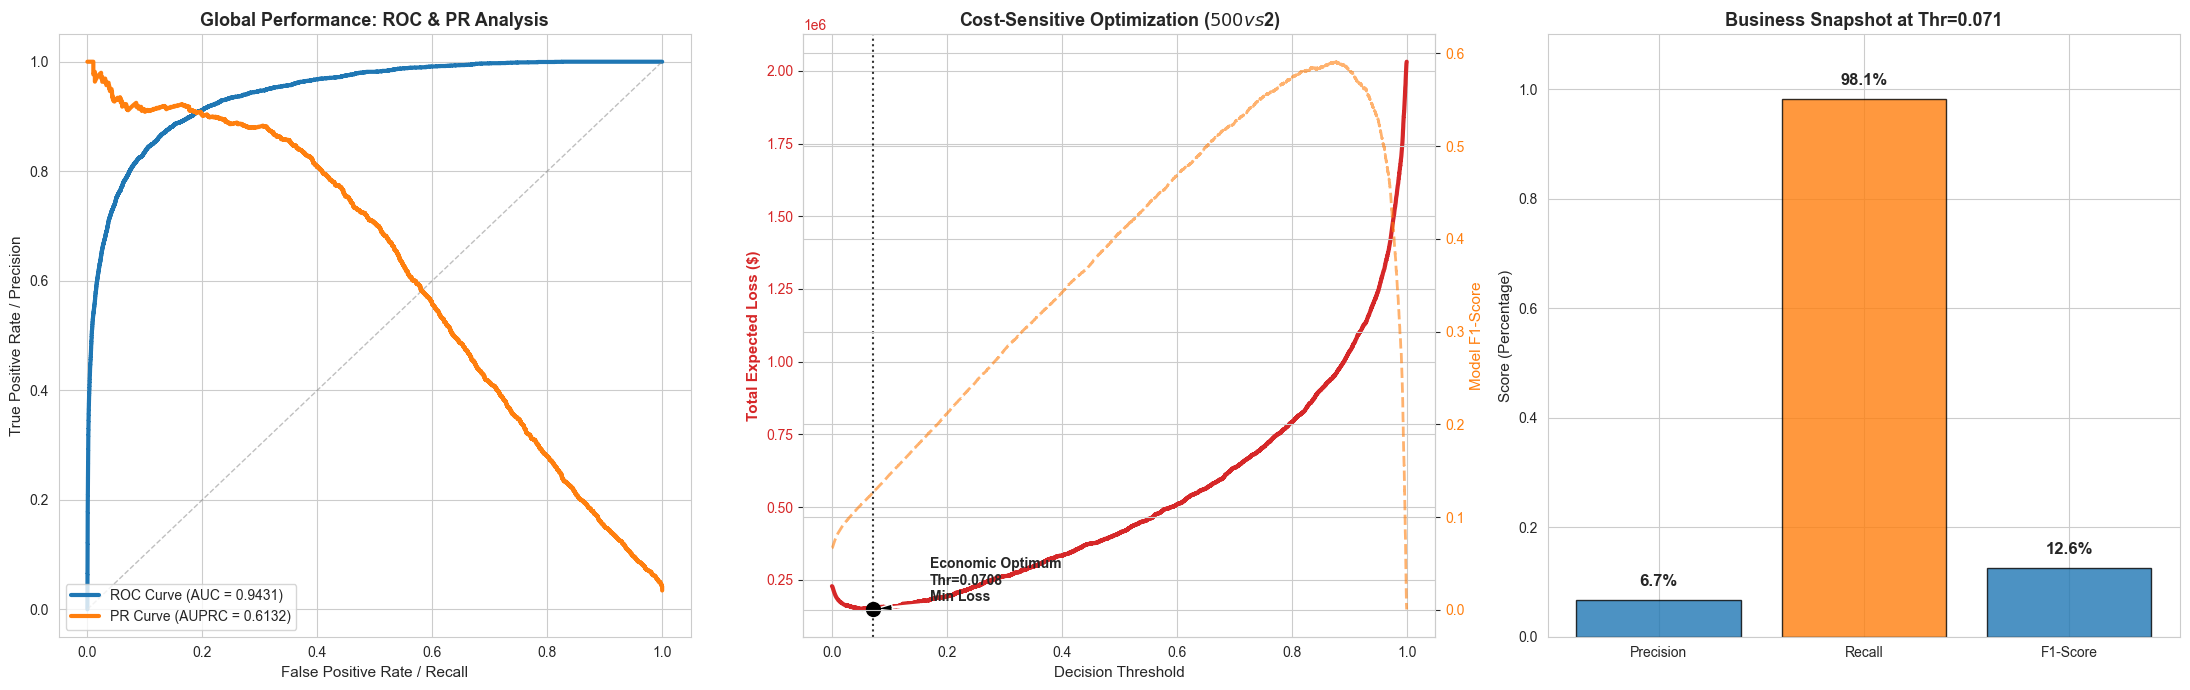

--- FINAL BUSINESS STRATEGY REPORT ---
1. Best Operational Threshold: 0.0708
2. Fraud Capture Rate (Recall): 98.13%
3. Detection Precision:         6.73%
4. Total Financial Exposure:    $148,464.00


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, average_precision_score

# --- 1. Environment & Style Configuration ---
sns.set_style("whitegrid")
primary_color = '#1f77b4' # Main Blue: Used for ROC/Metrics
cost_color = '#d62728'    # Alert Red: Used for Financial Loss
accent_color = '#ff7f0e'  # Emphasis Orange: Used for PR/F1

# --- 2. Initialize Canvas (Fix: Using plt.subplots for 1x3 Layout) ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=100)
plt.subplots_adjust(wspace=0.3)

# ==============================================================================
# Visualization 1: Global Performance Assessment (ROC vs. PR Curve)
# Logic: Proving model robustness across all possible thresholds.
# ==============================================================================
ax1 = axes[0]

# ROC Curve Calculation (General Discriminatory Power)
fpr, tpr, _ = roc_curve(y_test, y_scores_lgbm_full)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color=primary_color, lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5)

# PR Curve Calculation (Rule 5: Core Metric for Imbalanced Fraud Data)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores_lgbm_full)
auprc = average_precision_score(y_test, y_scores_lgbm_full)
ax1.plot(recall, precision, color=accent_color, lw=3, label=f'PR Curve (AUPRC = {auprc:.4f})')

ax1.set_xlabel('False Positive Rate / Recall', fontsize=11)
ax1.set_ylabel('True Positive Rate / Precision', fontsize=11)
ax1.set_title('Global Performance: ROC & PR Analysis', fontsize=13, fontweight='bold')
ax1.legend(loc='lower left', frameon=True)

# ==============================================================================
# Visualization 2: Cost-Sensitive Threshold Optimization ($500 vs $2)
# Logic: Identifying the "Economic Best" setting based on P&L impact (Rule 6).
# ==============================================================================
ax2 = axes[1]
costs = []
f1_scores = []

# Evaluate Financial Impact for every potential threshold
for t in pr_thresholds:
    y_pred = (y_scores_lgbm_full >= t).astype(int)
    
    # Calculate confusion elements using vectorized logic for speed
    tp = np.sum((y_test == 1) & (y_pred == 1))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    
    # Total Cost Function: Missed Fraud ($500) vs False Alarm ($2)
    total_cost = (fn * 500) + (fp * 2)
    costs.append(total_cost)
    
    # Standard F1 Calculation for reference
    p_temp = tp / (tp + fp + 1e-9)
    r_temp = tp / (tp + fn + 1e-9)
    f1_temp = 2 * (p_temp * r_temp) / (p_temp + r_temp + 1e-9)
    f1_scores.append(f1_temp)

# Identify the threshold that minimizes Total Loss
best_idx = np.argmin(costs)
best_threshold = pr_thresholds[best_idx]
min_loss = costs[best_idx]

# Plot Financial Loss (Primary Y-axis)
ax2.plot(pr_thresholds, costs, color=cost_color, lw=3, label='Financial Loss ($)')
ax2.set_ylabel('Total Expected Loss ($)', color=cost_color, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=cost_color)

# Plot F1-Score (Secondary Y-axis to show the trade-off)
ax2_f1 = ax2.twinx()
ax2_f1.plot(pr_thresholds, f1_scores, color=accent_color, lw=2, linestyle='--', alpha=0.6, label='F1-Score')
ax2_f1.set_ylabel('Model F1-Score', color=accent_color, fontsize=11)
ax2_f1.tick_params(axis='y', labelcolor=accent_color)

# Annotate the Economic Best Threshold
ax2.axvline(best_threshold, color='black', linestyle=':', alpha=0.8)
ax2.scatter(best_threshold, min_loss, color='black', s=100, zorder=5)
ax2.annotate(f'Economic Optimum\nThr={best_threshold:.4f}\nMin Loss', 
             xy=(best_threshold, min_loss), xytext=(best_threshold+0.1, min_loss*1.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

ax2.set_xlabel('Decision Threshold', fontsize=11)
ax2.set_title('Cost-Sensitive Optimization ($500 vs $2)', fontsize=13, fontweight='bold')

# ==============================================================================
# Visualization 3: Business Dashboard (Final Metrics at Best Threshold)
# Logic: Translating scores into actionable business KPIs.
# ==============================================================================
ax3 = axes[2]

# Generate predictions at the Economic Best threshold
y_pred_best = (y_scores_lgbm_full >= best_threshold).astype(int)
tp = np.sum((y_test == 1) & (y_pred_best == 1))
fp = np.sum((y_test == 0) & (y_pred_best == 1))
fn = np.sum((y_test == 1) & (y_pred_best == 0))

# Calculate final operational metrics
final_p = tp / (tp + fp)
final_r = tp / (tp + fn)
final_f1 = 2 * (final_p * final_r) / (final_p + final_r)

metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_vals = [final_p, final_r, final_f1]

# Render operational bar chart
bars = ax3.bar(metrics_names, metrics_vals, color=[primary_color, accent_color, primary_color], alpha=0.8, edgecolor='black')

# Add percentage data labels for clarity
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax3.set_ylim(0, 1.1)
ax3.set_title(f'Business Snapshot at Thr={best_threshold:.3f}', fontsize=13, fontweight='bold')
ax3.set_ylabel('Score (Percentage)', fontsize=11)

plt.tight_layout()
plt.show()

# --- Final Executive Conclusion ---
print(f"--- FINAL BUSINESS STRATEGY REPORT ---")
print(f"1. Best Operational Threshold: {best_threshold:.4f}")
print(f"2. Fraud Capture Rate (Recall): {final_r*100:.2f}%")
print(f"3. Detection Precision:         {final_p*100:.2f}%")
print(f"4. Total Financial Exposure:    ${min_loss:,.2f}")